# MRP: empirical distributions and the CLT

This notebook compares the empirical marginal distributions of $\sqrt{T}(\bar{\theta}_T-\theta^\star)$ with the Gaussian CLT limit at $T=2^{10},2^{15},2^{20}$. Rows correspond to coordinates of $\theta$ and columns correspond to sample sizes.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml

ROOT = Path.cwd()
if not (ROOT / 'models.py').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from models import MRP

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'axes.linewidth': 0.8,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

Matplotlib is building the font cache; this may take a moment.


In [2]:
experiment_dir = ROOT / 'results' / '01'
with (experiment_dir / 'config.yaml').open() as stream:
    config = yaml.safe_load(stream)

results = np.load(experiment_dir / 'results.npy')
model = MRP(config['model_param'], seed=0)
theta_star = model.theta_star
clt_covariance = model.calculate_clt_variance()

exponents = (10, 15, 20)
sample_sizes = tuple(2**k for k in exponents)
save_positions = {t: i for i, t in enumerate(config['save_iter'])}
missing = [t for t in sample_sizes if t not in save_positions]
if missing:
    raise ValueError(f'Results do not contain requested iterations: {missing}')
if results.ndim != 3 or results.shape[2] != model.d:
    raise ValueError(f'Unexpected results shape: {results.shape}')

print(f'Loaded {results.shape[0]:,} trials with {model.d} dimensions.')
print('CLT covariance:\n', clt_covariance)

Loaded 10,000 trials with 3 dimensions.
CLT covariance:
 [[ 0.07536233 -0.00982988  0.05053669]
 [-0.00982988  0.05701806 -0.01317303]
 [ 0.05053669 -0.01317303  0.16061129]]


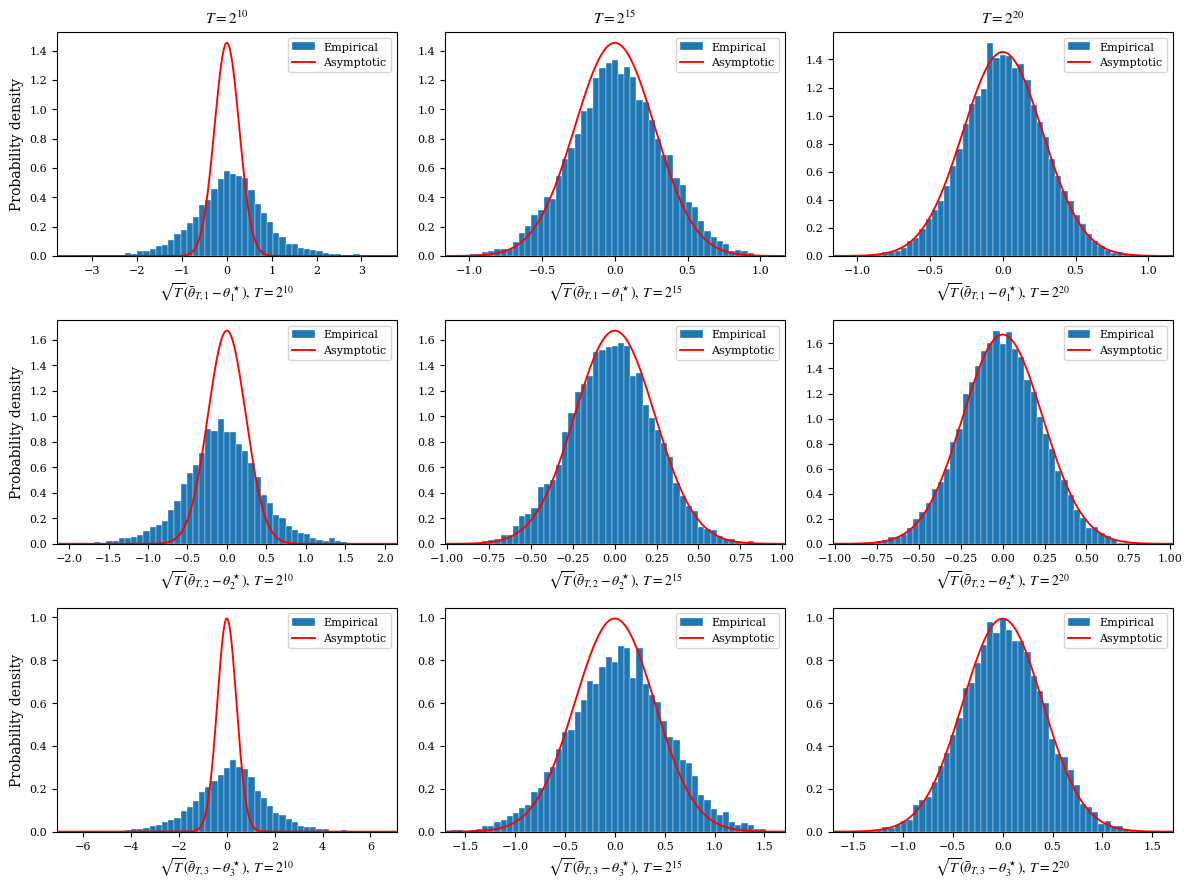

Saved figure to /Users/weichen_wu_1996/Desktop/Research/github/SA_CLT_CRLB/results/01/mrp_clt_histograms.pdf


In [3]:
def normal_density(x, variance):
    return np.exp(-0.5 * x**2 / variance) / np.sqrt(2 * np.pi * variance)

fig, axes = plt.subplots(model.d, len(sample_sizes), figsize=(12, 9))
histogram_color = '#1f77b4'
density_color = 'red'

for column, (k, T) in enumerate(zip(exponents, sample_sizes)):
    saved = results[:, save_positions[T], :]
    scaled_errors = np.sqrt(T) * (saved - theta_star)

    for dimension in range(model.d):
        ax = axes[dimension, column]
        values = scaled_errors[:, dimension]
        variance = clt_covariance[dimension, dimension]
        standard_deviation = np.sqrt(variance)

        # Retain essentially all observations while preventing a few
        # transient outliers from flattening the histogram.
        lower, upper = np.quantile(values, [0.001, 0.999])
        bound = max(abs(lower), abs(upper), 4.25 * standard_deviation)
        x_grid = np.linspace(-bound, bound, 600)

        ax.hist(
            values, bins=55, range=(-bound, bound), density=True,
            color=histogram_color, edgecolor='white', linewidth=0.25,
            label='Empirical',
        )
        ax.plot(
            x_grid, normal_density(x_grid, variance),
            color=density_color, linewidth=1.35, label='Asymptotic',
        )
        ax.set_xlim(-bound, bound)
        ax.set_xlabel(
            rf'$\sqrt{{T}}(\bar{{\theta}}_{{T,{dimension + 1}}}'
            rf'-\theta^\star_{{{dimension + 1}}}),\;T=2^{{{k}}}$'
        )
        if column == 0:
            ax.set_ylabel('Probability density')
        if dimension == 0:
            ax.set_title(rf'$T=2^{{{k}}}$')
        ax.legend(loc='upper right', frameon=True)
        ax.grid(False)

fig.tight_layout(pad=1.1, w_pad=1.0, h_pad=1.2)
output_path = experiment_dir / 'mrp_clt_histograms.pdf'
fig.savefig(output_path, bbox_inches='tight')
plt.show()
print(f'Saved figure to {output_path}')